# 1. Dashboard Proyecto Visualización de datos — Dataset: Employee Mental Health & Burnout

### Integrantes: 
 Clotilde Véliz Véliz <br>
 Cristóbal Fritz Camus

Análisis exploratorio general del dataset: dimensiones, tipos de datos, valores nulos, distribuciones y relaciones básicas.

## 1.1. Carga y vista general

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("tech_mental_health_burnout.csv")
print(f"Dataset cargado con {df.shape[0]:,} filas y {df.shape[1]} columnas.")
df.head()

Dataset cargado con 150,000 filas y 25 columnas.


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


## 1.2.  Tipos de datos y valores nulos

In [22]:
# Resumen de tipos y nulos
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
print(info_df.to_string())

                            Tipo  Nulos  % Nulos  Únicos
age                        int64      0      0.0      33
gender                    object      0      0.0       3
job_role                  object      0      0.0       8
experience_years         float64      0      0.0     172
company_size              object      0      0.0       4
work_mode                 object      0      0.0       3
work_hours_per_week      float64      0      0.0      52
overtime_hours           float64      0      0.0      25
meetings_per_day         float64      0      0.0      13
deadlines_missed           int64      0      0.0       6
job_satisfaction         float64      0      0.0      91
manager_support          float64      0      0.0      91
work_life_balance        float64      0      0.0      91
sleep_hours              float64      0      0.0      71
physical_activity_days     int64      0      0.0       8
screen_time_hours        float64      0      0.0     127
caffeine_intake            int6

In [23]:
# Visualización de valores nulos
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

if len(nulos) > 0:
    plt.figure(figsize=(8, 4))
    nulos.plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Columnas con valores nulos')
    plt.ylabel('Cantidad de nulos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Sin valores nulos en el dataset.")

Sin valores nulos en el dataset.


## 1.3. Estadísticas descriptivas

In [24]:
df.describe().round(2)

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.0,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.0
mean,38.03,5.06,47.01,6.13,4.01,1.28,5.50,5.50,5.02,6.50,2.60,8.00,2.1,5.50,0.25,5.79,4.52,3.10,2.11,0.1
std,9.51,2.88,7.89,3.78,1.98,1.43,1.96,1.96,1.95,1.19,1.81,1.99,1.3,1.96,0.43,1.33,1.20,1.19,1.11,0.3
min,22.00,0.00,30.00,0.00,0.00,0.00,1.00,1.00,1.00,3.00,0.00,3.00,0.0,1.00,0.00,1.00,1.00,1.00,1.00,0.0
25%,30.00,3.00,42.00,3.00,3.00,0.00,4.20,4.10,3.70,5.70,1.00,6.70,1.0,4.20,0.00,4.90,3.70,2.20,1.00,0.0
50%,38.00,5.00,47.00,6.00,4.00,1.00,5.50,5.50,5.00,6.50,2.00,8.00,2.0,5.50,0.00,5.80,4.50,3.10,1.90,0.0
75%,46.00,7.00,52.00,9.00,5.00,2.00,6.90,6.80,6.40,7.30,4.00,9.30,3.0,6.80,1.00,6.70,5.30,3.90,2.80,0.0
max,54.00,18.50,84.00,24.00,12.00,5.00,10.00,10.00,10.00,10.00,7.00,16.00,5.0,10.00,1.00,10.00,9.60,8.10,8.10,1.0


## 1.4. Distribuciones de variables categóricas

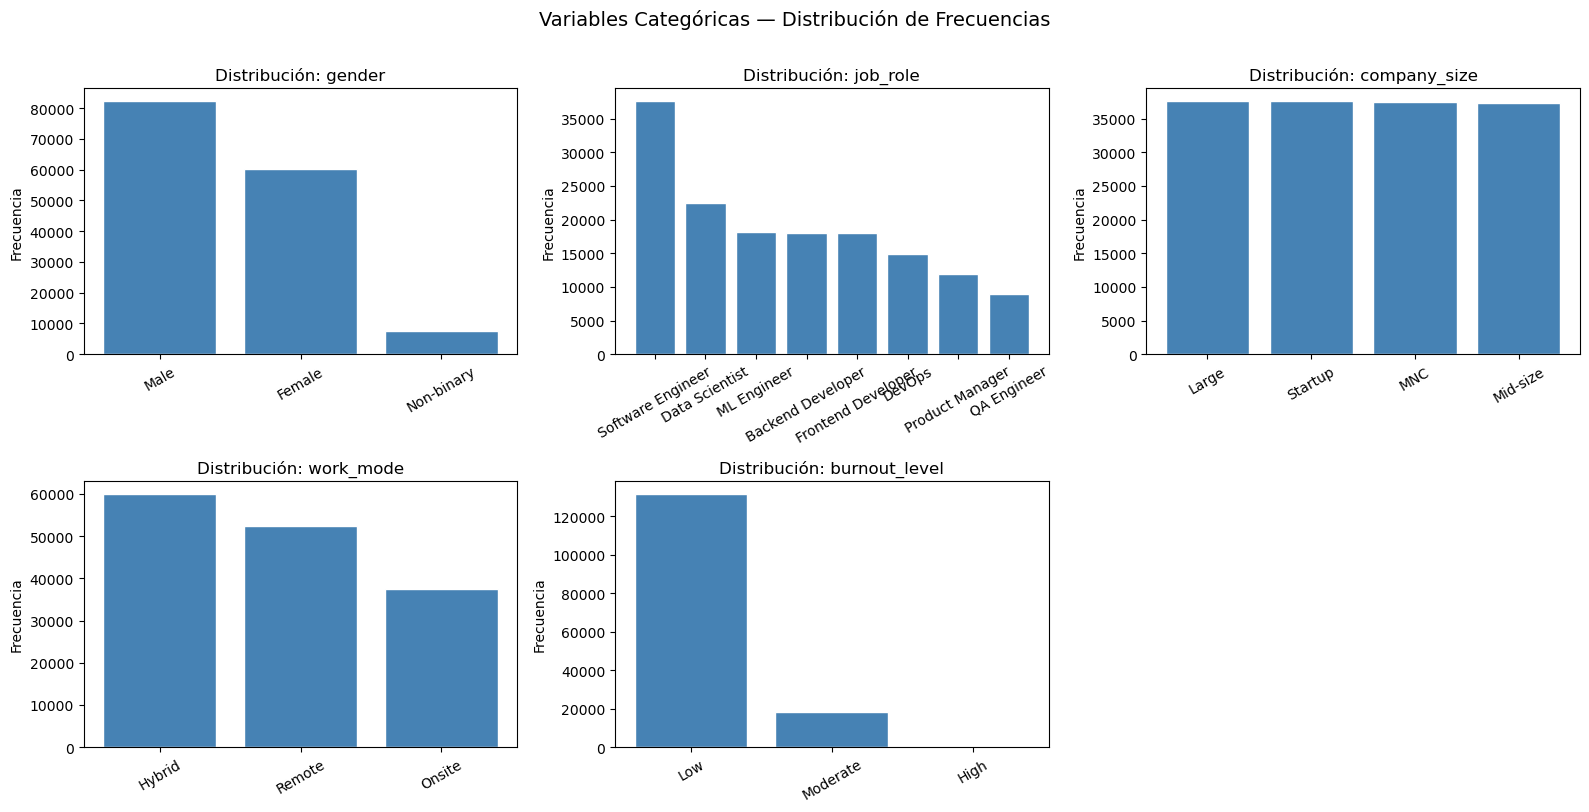

In [25]:
cat_cols = ['gender', 'job_role', 'company_size', 'work_mode', 'burnout_level']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].axis('off')
plt.suptitle('Variables Categóricas — Distribución de Frecuencias', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.5. Distribuciones de variables numéricas clave

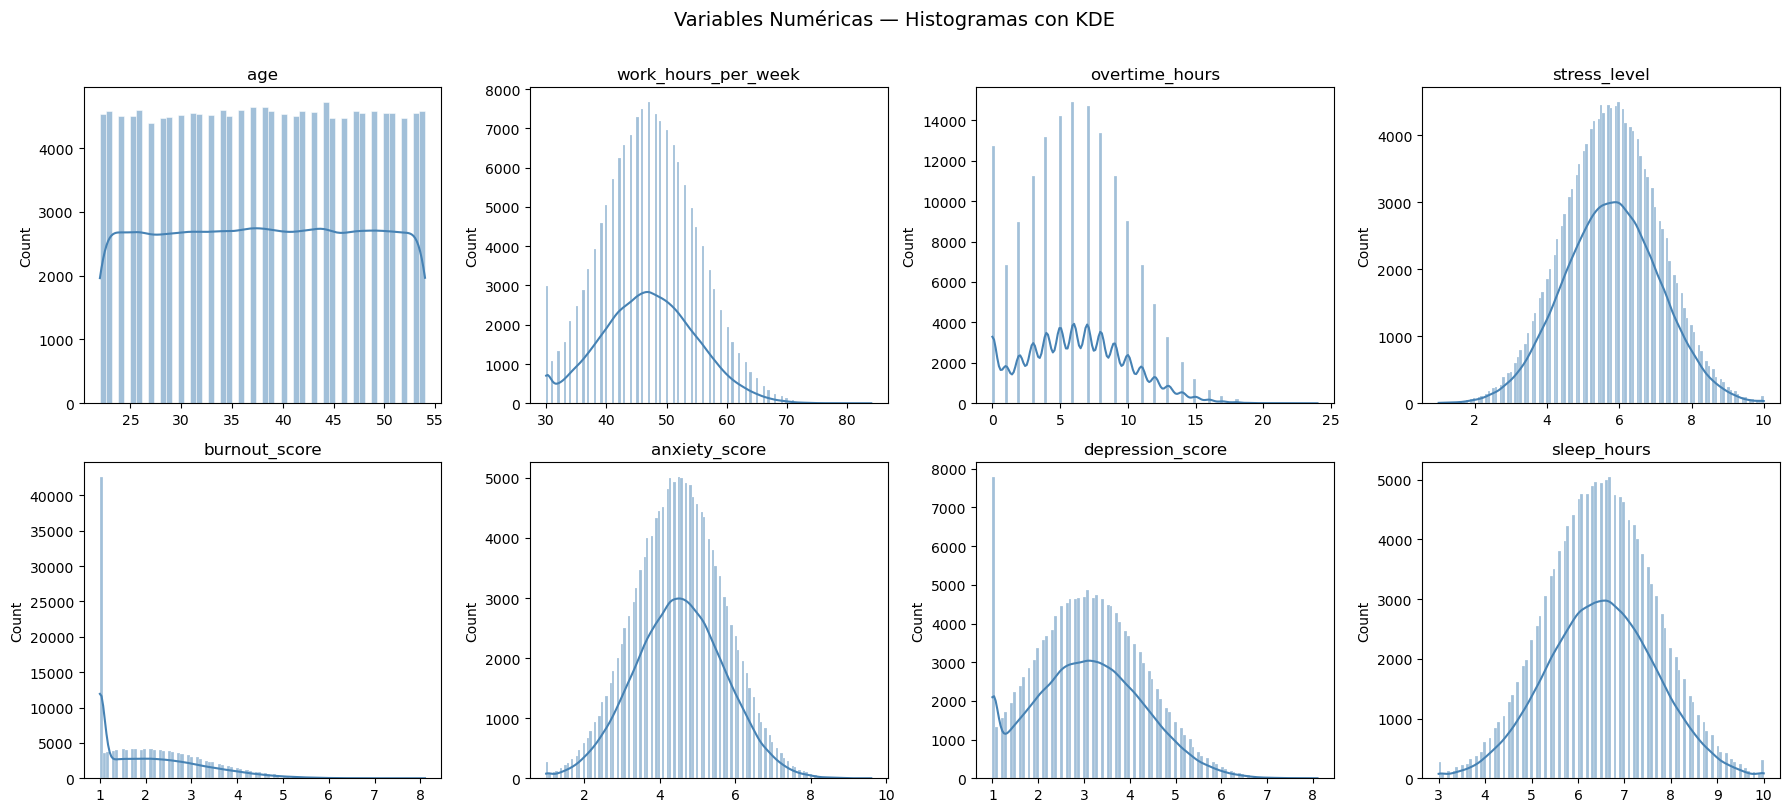

In [26]:
num_cols = ['age', 'work_hours_per_week', 'overtime_hours', 'stress_level',
            'burnout_score', 'anxiety_score', 'depression_score', 'sleep_hours']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), ax=axes[i], kde=True, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Variables Numéricas — Histogramas con KDE', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.6. Distribucion  de variables binarias

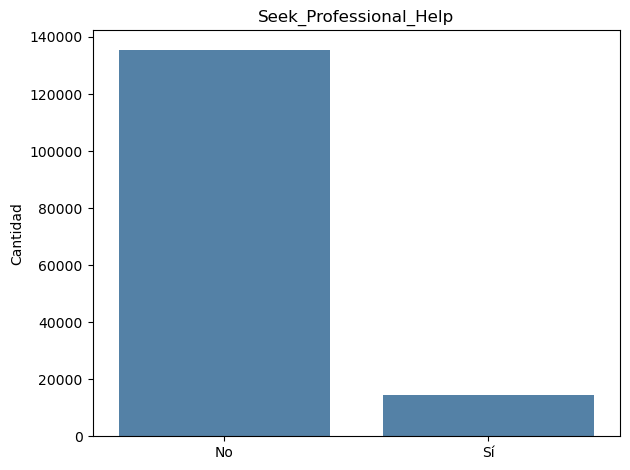

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir a string primero
df['seeks_professional_help'] = df['seeks_professional_help'].astype(str)

# Limpiar valores
df['seeks_professional_help'] = df['seeks_professional_help'].str.strip().str.lower()

# Mapear valores a algo consistente
df['seeks_professional_help'] = df['seeks_professional_help'].replace({
    'yes': 'Sí',
    'true': 'Sí',
    '1': 'Sí',
    'no': 'No',
    'false': 'No',
    '0': 'No',
    'nan': 'Sin dato'
})

# Graficar
sns.countplot(x=df['seeks_professional_help'], color='steelblue')

plt.title('Seek_Professional_Help')
plt.xlabel('')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.show()


## 1.7. Distribución de burnout por variables categóricas

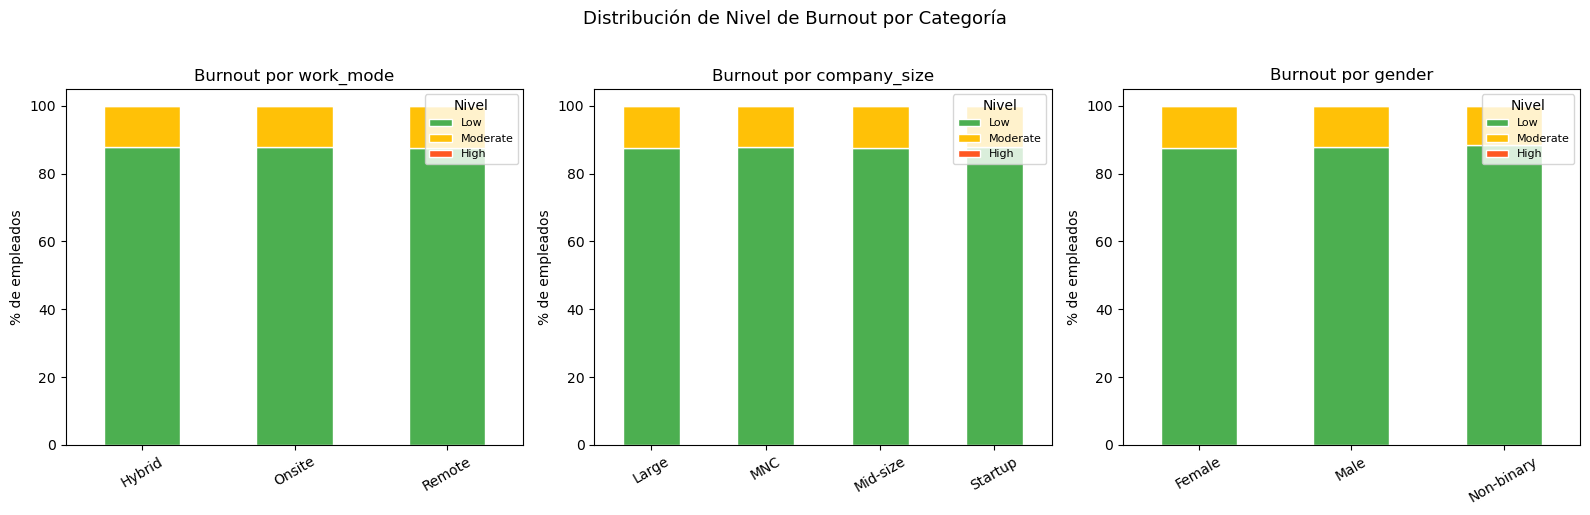

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['work_mode', 'company_size', 'gender']):
    orden_burnout = ['Low', 'Moderate', 'High', 'Critical']
    ct = pd.crosstab(df[col], df['burnout_level'])
    ct = ct.reindex(columns=[c for c in orden_burnout if c in ct.columns])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=ax,
                color=['#4CAF50', '#FFC107', '#FF5722', '#9C27B0'],
                edgecolor='white')
    ax.set_title(f'Burnout por {col}')
    ax.set_ylabel('% de empleados')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Nivel', fontsize=8, loc='upper right')

plt.suptitle('Distribución de Nivel de Burnout por Categoría', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 1.8. Promedios de scores por rol

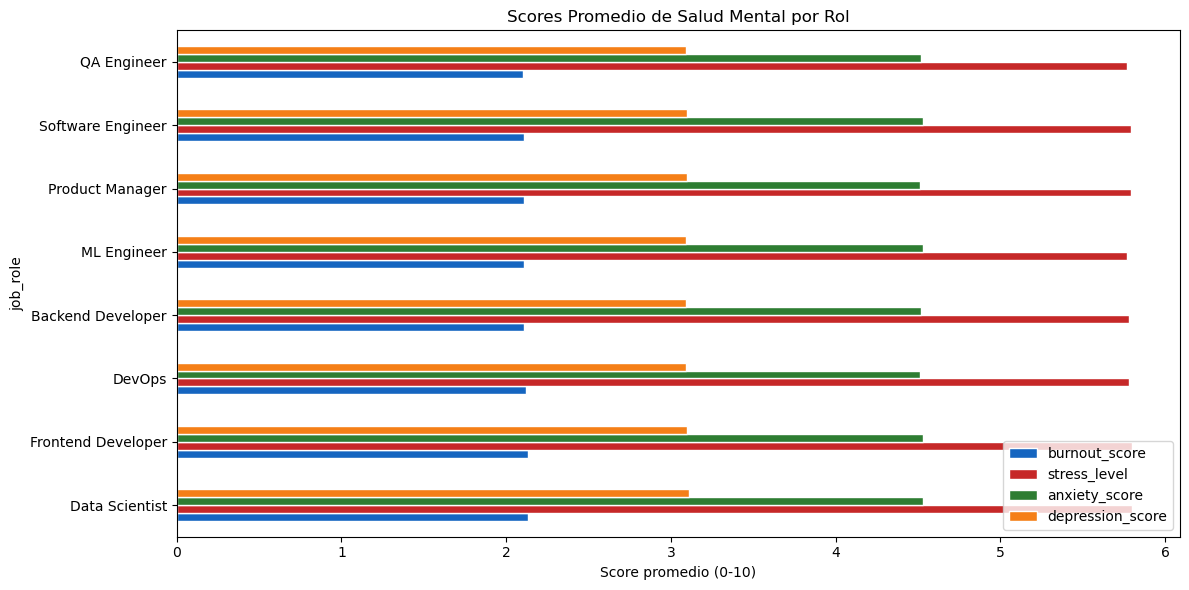

In [29]:
scores = ['burnout_score', 'stress_level', 'anxiety_score', 'depression_score']
avg_por_rol = df.groupby('job_role')[scores].mean().round(2).sort_values('burnout_score', ascending=False)

avg_por_rol.plot(kind='barh', figsize=(12, 6),
                 color=['#1565C0', '#C62828', '#2E7D32', '#F57F17'],
                 edgecolor='white')

plt.title('Scores Promedio de Salud Mental por Rol')
plt.xlabel('Score promedio (0-10)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 1.9. Mapa de correlaciones

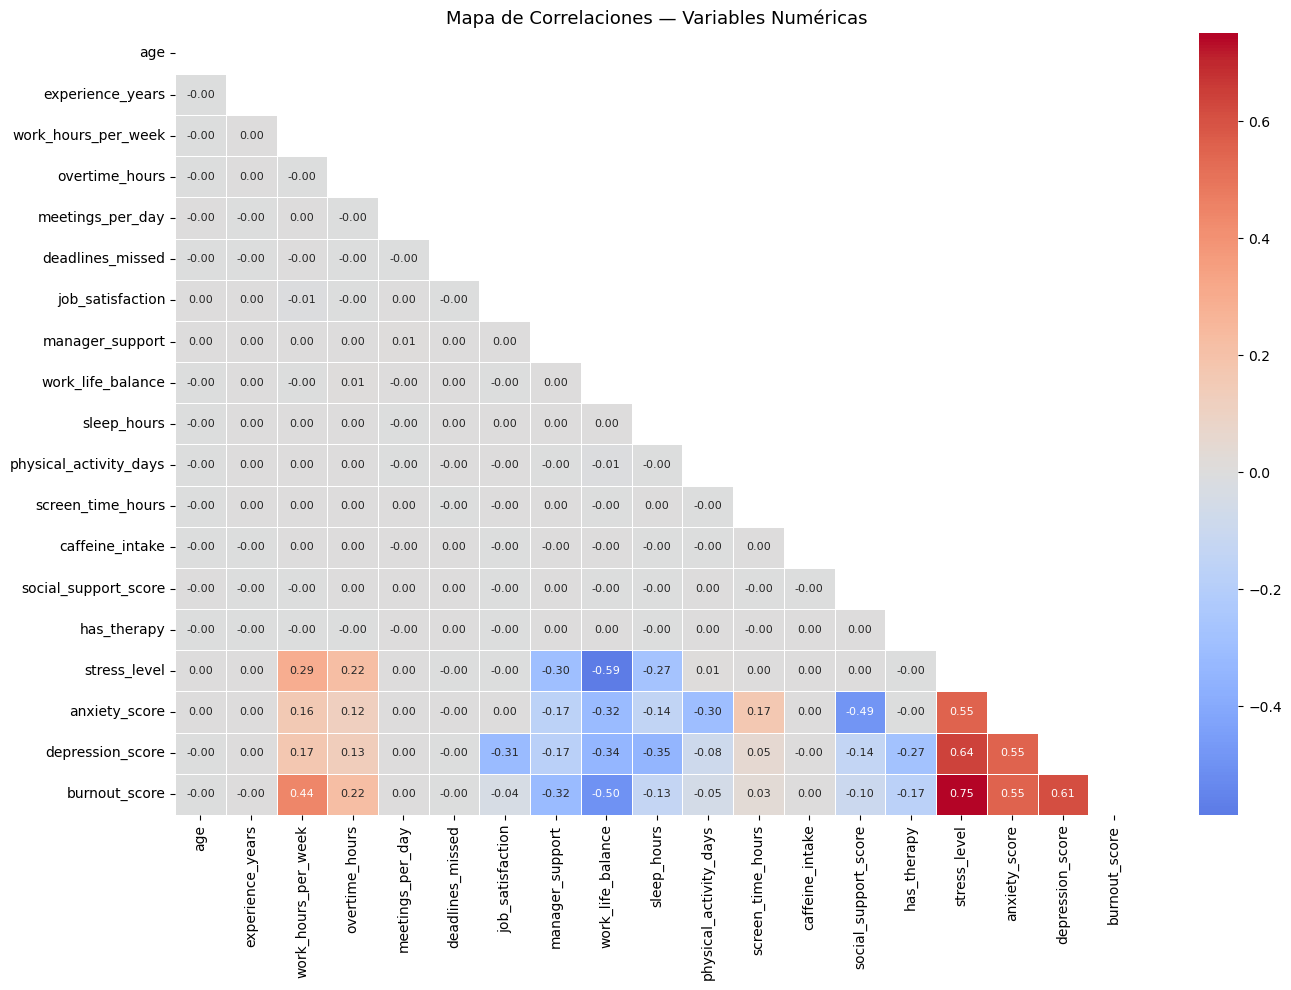

In [30]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Mapa de Correlaciones — Variables Numéricas', fontsize=13)
plt.tight_layout()
plt.show()

## 1.10. Relación horas trabajadas vs. burnout score

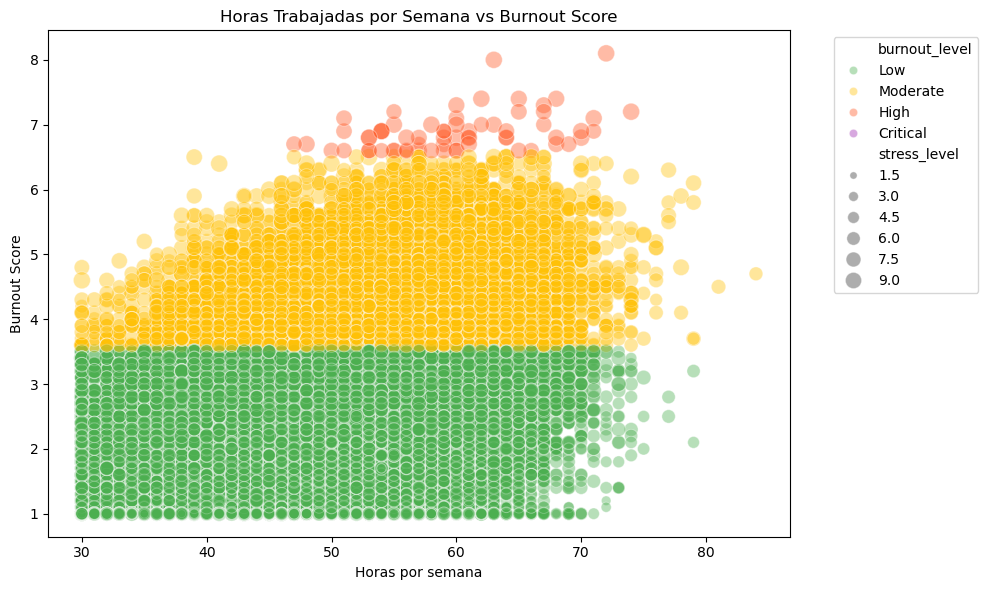

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='work_hours_per_week', y='burnout_score',
                hue='burnout_level', alpha=0.4, size='stress_level',
                sizes=(20, 150),
                hue_order=['Low', 'Moderate', 'High', 'Critical'],
                palette=['#4CAF50', '#FFC107', '#FF5722', '#9C27B0'])

plt.title('Horas Trabajadas por Semana vs Burnout Score')
plt.xlabel('Horas por semana')
plt.ylabel('Burnout Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

# 1.11 Cálculos adicionales

In [32]:
# KPI 1
avg_burnout_score = df['burnout_score'].mean()

# KPI 2
# Normalizar columna
df['seeks_professional_help'] = df['seeks_professional_help'].astype(str).str.strip().str.lower()

# Convertir a binario
df['seeks_professional_help'] = (
    df['seeks_professional_help']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'yes': 1,
        'sí': 1,
        'si': 1,
        'true': 1,
        '1': 1,
        'no': 0,
        'false': 0,
        '0': 0
    })
    .astype(int)
)

# KPI 2 ahora sí funciona
pct_help_seeking = df['seeks_professional_help'].mean() * 100

# KPI 3
pct_high_burnout = (df['burnout_level'] == 'high').mean() * 100

# KPI 4
avg_burnout_women = df[df['gender'] == 'Female']['burnout_score'].mean()

# KPI 5
avg_burnout_men = df[df['gender'] == 'Male']['burnout_score'].mean()

# Porcentaje de hombres vs mujeres

mujeres = df[df['gender'] == 'Female']
hombres = df[df['gender'] == 'Male']

promedio_mujeres = df[df['gender'] == 'Female']['burnout_score'].mean()
promedio_hombres = df[df['gender'] == 'Male']['burnout_score'].mean()

print(f"Mujeres: {len(mujeres)}")
print(f"Hombres: {len(hombres)}")

print(f"Promedio burnout: {avg_burnout_score:.2f}")
print(f"% buscan ayuda: {pct_help_seeking:.2f}%")
print(f"% burnout alto: {pct_high_burnout:.5f}%")
print(f"Burnout promedio mujeres: {avg_burnout_women:.2f}")
print(f"Burnout promedio hombres: {avg_burnout_men:.2f}")


Mujeres: 60281
Hombres: 82286
Promedio burnout: 2.11
% buscan ayuda: 9.63%
% burnout alto: 0.00000%
Burnout promedio mujeres: 2.11
Burnout promedio hombres: 2.11


C:\Users\cristobal\AppData\Local\Temp\ipykernel_9744\1912805375.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


# 2. Ingeniería de características (nuevas columnas para el dashboard)

## 2.1. Categorizar la edad en rangos para ver quién sufre más burnout.

In [33]:
bins_edad = [18, 25, 35, 45, 60]
labels_edad = ['Gen Z (18-25)', 'Millennials (26-35)', 'Gen X (36-45)', 'Senior (46+)']
df['age_group'] = pd.cut(df['age'], bins=bins_edad, labels=labels_edad)
df['age_group'].value_counts()

age_group
Gen X (36-45)          45836
Millennials (26-35)    45163
Senior (46+)           40885
Gen Z (18-25)          18116
Name: count, dtype: int64

# 3. Dashboard

In [34]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import base64
from io import BytesIO
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# PALETA Y ESTILOS GLOBALES
# ─────────────────────────────────────────
BG        = "#F4F6FB"
CARD_BG   = "#FFFFFF"
ACCENT1   = "#1A2744"
ACCENT2   = "#ED6A5A"
ACCENT3   = "#9BC1BC"
ACCENT4   = "#5B6EB5"
FONT      = "Segoe UI, sans-serif"

KPI_COLORS = {                       # Colores para los KPIs generales
    "burnout":  "#E8401C",
    "help":     "#2AA876",
    "risk":     "#F0A500",
    "gender_f": "#9B59B6",
    "gender_m": "#3498DB",
}

ORDER_BURNOUT = ["Low", "Moderate", "High"]   # Colores para los niveles del burnout
CMAP_BURNOUT = {
    "Low":      "#9BC1BC",
    "Moderate": "#ED6A5A",
    "High":     "#8B0000",
}

EXCLUIR = ["seeks_professional_help"]

# ─────────────────────────────────────────
# NIVEL DE BURNOUT SEGUN SCORE
# ─────────────────────────────────────────
def burnout_level_label(score):
    if score < 3.5:
        return "Low", "#9BC1BC"
    elif score < 6.5:
        return "Moderate", "#ED6A5A"
    else:
        return "High", "#8B0000"

# ─────────────────────────────────────────
# TOP 10 IMPORTANCIA ( Calculado con Random Forest en diferente notebook)
# ─────────────────────────────────────────
IMP_BURNOUT = pd.DataFrame([
    {"variable": "work_life_balance",       "importance": 0.2189},
    {"variable": "work_hours_per_week",     "importance": 0.1856},
    {"variable": "manager_support",         "importance": 0.1391},
    {"variable": "overtime_hours",          "importance": 0.0531},
    {"variable": "social_support_score",    "importance": 0.0470},
    {"variable": "sleep_hours",             "importance": 0.0443},
    {"variable": "job_satisfaction",        "importance": 0.0359},
    {"variable": "experience_years",        "importance": 0.0317},
    {"variable": "screen_time_hours",       "importance": 0.0315},
    {"variable": "seeks_professional_help", "importance": 0.0531},
]).sort_values("importance", ascending=True)

IMP_HELP = pd.DataFrame([
    {"variable": "burnout_score",        "importance": 0.1260},
    {"variable": "anxiety_score",        "importance": 0.1020},
    {"variable": "stress_level",         "importance": 0.0775},
    {"variable": "depression_score",     "importance": 0.0620},
    {"variable": "work_life_balance",    "importance": 0.0525},
    {"variable": "manager_support",      "importance": 0.0500},
    {"variable": "social_support_score", "importance": 0.0495},
    {"variable": "burnout_level",        "importance": 0.0475},
    {"variable": "experience_years",     "importance": 0.0470},
    {"variable": "screen_time_hours",    "importance": 0.0460},
]).sort_values("importance", ascending=True)

VAR_LABELS = {
    "work_life_balance":       "Work-Life Balance",
    "work_hours_per_week":     "Work Hours / Week",
    "manager_support":         "Manager Support",
    "overtime_hours":          "Overtime Hours",
    "social_support_score":    "Social Support Score",
    "sleep_hours":             "Sleep Hours",
    "job_satisfaction":        "Job Satisfaction",
    "experience_years":        "Experience Years",
    "screen_time_hours":       "Screen Time Hours",
    "seeks_professional_help": "Seeks Professional Help",
    "burnout_score":           "Burnout Score",
    "anxiety_score":           "Anxiety Score",
    "stress_level":            "Stress Level",
    "depression_score":        "Depression Score",
    "burnout_level":           "Burnout Level",
    "age":                     "Age",
}

def readable(v):
    return VAR_LABELS.get(v, v.replace("_", " ").title())

# ─────────────────────────────────────────
# GRADIENTE para barras RF basada en #ED6A5A
# ─────────────────────────────────────────
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

def interpolate_color(color1_hex, color2_hex, t):
    r1, g1, b1 = hex_to_rgb(color1_hex)
    r2, g2, b2 = hex_to_rgb(color2_hex)
    r = int(r1 + (r2 - r1) * t)
    g = int(g1 + (g2 - g1) * t)
    b = int(b1 + (b2 - b1) * t)
    return f"#{r:02x}{g:02x}{b:02x}"

def build_importance_fig(imp_df, target):
    imp_sorted = imp_df.sort_values("importance", ascending=False).copy()
    imp_sorted["label"] = imp_sorted["variable"].map(readable)

    title = ("Top 10 - Variables importantes - Burnout Level"
             if target == "burnout_level"
             else "Top 10 - Varieble importantes - Busca Ayuda Profesional")

    COLOR_LOW  = "#FADADD"
    COLOR_HIGH = "#ED6A5A"

    imp_vals = imp_sorted["importance"].values
    imp_min, imp_max = imp_vals.min(), imp_vals.max()
    ts = [(v - imp_min) / (imp_max - imp_min) if imp_max != imp_min else 1.0
          for v in imp_vals]
    colors = [interpolate_color(COLOR_LOW, COLOR_HIGH, t) for t in ts]
    imp_sorted["color"] = colors

    imp_sorted = imp_sorted.sort_values("importance", ascending=True)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=imp_sorted["importance"],
        y=imp_sorted["label"],
        orientation="h",
        marker_color=imp_sorted["color"],
        text=[f"{v*100:.1f}%" for v in imp_sorted["importance"]],
        textposition="outside",
        cliponaxis=False,
    ))
    fig.update_layout(
        title=dict(
            text=title,
            font=dict(size=12, color=ACCENT1),
            x=0.5,
            xanchor="center",
        ),
        xaxis=dict(
            showticklabels=False,
            showgrid=False,
            zeroline=False,
            title=None,
        ),
        yaxis=dict(
            automargin=True,
            tickfont=dict(size=13),
        ),
        paper_bgcolor=CARD_BG,
        plot_bgcolor=CARD_BG,
        margin=dict(l=10, r=80, t=45, b=10),
        height=380,
        showlegend=False,
        bargap=0.5,
    )
    return fig


# ─────────────────────────────────────────
# WORDCLOUD DE PERFILES — ESTÁTICO (en función a 3 variables = job:role, work_mode, company_size)
# ─────────────────────────────────────────
_wc_cache = None

def make_profile_wordcloud_static(df_full):
    global _wc_cache
    if _wc_cache is not None:
        return _wc_cache

    df2 = df_full.copy()
    df2["mode_abbr"] = df2["work_mode"].str[0]
    size_map = {"Small": "S", "Medium": "M", "Large": "L", "MNC": "MNC"}
    df2["size_abbr"] = df2["company_size"].map(size_map).fillna(df2["company_size"].str[0])
    df2["perfil"] = (
        df2["job_role"].str.replace(" ", "") + "_" +
        df2["mode_abbr"] + "_" +
        df2["size_abbr"]
    )
    df_grouped = df2.groupby("perfil")["burnout_score"].mean()
    freq = df_grouped.to_dict()
    wc = WordCloud(
        width=1100, height=580, background_color="white",
        colormap="RdYlGn_r", max_font_size=90, min_font_size=10,
        prefer_horizontal=0.80, margin=6,
    ).generate_from_frequencies(freq)
    buf = BytesIO()
    fig_wc, ax = plt.subplots(figsize=(11, 4), dpi=90)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    legend_text = (
        "Modo de Trabajo:\n"
        "R = Remote\nH = Hybrid\nO = On-site\n\n"
        "Tamano Empresa:\nS   = Small\nM   = Medium\nL   = Large\nMNC = MNC"
    )
    ax.text(1.01, 0.5, legend_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='center',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#F8FAFF",
                      edgecolor="#CCCCCC", alpha=0.9),
            fontfamily="monospace")
    fig_wc.patch.set_facecolor("white")
    plt.tight_layout(pad=0.3)
    fig_wc.savefig(buf, format="png", bbox_inches="tight", facecolor="white", dpi=90)
    plt.close(fig_wc)
    buf.seek(0)
    result = "data:image/png;base64," + base64.b64encode(buf.read()).decode()
    _wc_cache = result
    return result


# ─────────────────────────────────────────
# SCATTER BURBUJA
# ─────────────────────────────────────────
def make_bubble_scatter(dff, xvar, yvar="burnout_score", xlabel=None):
    if xvar not in dff.columns:
        return go.Figure()
    tmp = dff[[xvar, yvar, "burnout_level"]].dropna().copy()
    tmp["xr"] = tmp[xvar].round(1)
    tmp["yr"] = tmp[yvar].round(1)
    grp = tmp.groupby(["xr", "yr", "burnout_level"]).size().reset_index(name="count")

    x_display = xlabel if xlabel else readable(xvar)
    y_display = readable(yvar)

    fig = go.Figure()
    for lvl in ORDER_BURNOUT:
        sub = grp[grp["burnout_level"] == lvl]
        fig.add_trace(go.Scatter(
            x=sub["xr"] if not sub.empty else [],
            y=sub["yr"] if not sub.empty else [],
            mode="markers",
            name=lvl,
            visible=True,
            marker=dict(
                size=sub["count"].clip(upper=80) if not sub.empty else [],
                sizemode="area",
                sizeref=2.0 * grp["count"].max() / (30 ** 2) if not grp.empty else 1,
                sizemin=4,
                color=CMAP_BURNOUT.get(lvl, "#CCCCCC"),
                opacity=0.75,
                line=dict(width=0.5, color="#FFFFFF"),
            ),
            hovertemplate=(
                f"<b>{x_display}</b>: %{{x}}<br><b>{y_display}</b>: %{{y}}<br>"
                "<b>Level</b>: %{fullData.name}<br><b>People</b>: %{marker.size}<extra></extra>"
            )
        ))

    if len(tmp) > 2:
        z = np.polyfit(tmp[xvar], tmp[yvar], 1)
        p = np.poly1d(z)
        xr = np.linspace(tmp[xvar].min(), tmp[xvar].max(), 60)
        fig.add_trace(go.Scatter(
            x=xr, y=p(xr), mode="lines",
            line=dict(color=ACCENT1, width=1.5, dash="dash"),
            name="Trend",
            showlegend=True,
        ))

    fig.update_layout(
        paper_bgcolor=CARD_BG,
        plot_bgcolor=CARD_BG,
        margin=dict(l=60, r=20, t=20, b=60),
        showlegend=True,
        legend=dict(orientation="h", y=1.08, font=dict(size=10), title_text=""),
        # ── CAMBIO: ejes con línea visible y títulos ──
        xaxis=dict(
            title=x_display,
            title_font=dict(size=11, color=ACCENT1),
            showgrid=True,
            gridcolor="#F0F0F0",
            zeroline=False,
            showline=True,
            linecolor="#CCCCCC",
            linewidth=1.5,
            mirror=False,
        ),
        yaxis=dict(
            title=y_display,
            title_font=dict(size=11, color="#9BC1BC"),
            tickfont=dict(color="#9BC1BC"),
            showgrid=True,
            gridcolor="#F0F0F0",
            zeroline=False,
            showline=True,
            linecolor="#CCCCCC",
            linewidth=1.5,
            mirror=False,
        ),
    )
    return fig


# ─────────────────────────────────────────
# ESTILOS
# ─────────────────────────────────────────
CARD_STYLE = {
    "backgroundColor": CARD_BG, "borderRadius": "10px",
    "padding": "14px 16px", "boxShadow": "0 2px 12px rgba(0,0,0,0.07)",
    "boxSizing": "border-box",
}
SECTION_TITLE = {
    "color": ACCENT1, "margin": "0 0 8px 0", "fontSize": "10px",
    "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.7px",
}

def kpi_card_profile(title, value_general, value_profile, color, unit="", is_pct=False):     # KPIs de los perfiles filtrados 
    try:
        diff = float(value_profile) - float(value_general)
        arrow = "▲" if diff > 0 else "▼" if diff < 0 else "●"
        diff_color = "#e74c3c" if diff > 0 else "#27ae60" if diff < 0 else "#888"
        suffix = " pp" if is_pct else ""
        diff_text = f"{arrow} {abs(diff):.1f}{suffix} vs general"
    except Exception:
        diff_text = ""
        diff_color = "#888"
    return html.Div([
        html.P(title, style={"margin": "0 0 1px 0", "fontSize": "8.5px", "color": "#888",
                             "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.3px"}),
        html.H3(f"{float(value_profile):.1f}{unit}", style={"margin": "0", "color": color,
                                                              "fontSize": "17px", "fontWeight": "800"}),
        html.P(diff_text, style={"margin": "1px 0 0 0", "fontSize": "9px",
                                  "color": diff_color, "fontWeight": "600"}),
    ], style={"backgroundColor": "#f8faff", "borderRadius": "7px", "padding": "7px 10px",
               "borderLeft": f"3px solid {color}", "marginBottom": "5px", "boxSizing": "border-box"})


# ─────────────────────────────────────────
# GLOSARIO
# ─────────────────────────────────────────
GLOSARIO_ITEMS = [
    ("Burnout Score", "Puntuación de 0 a 10 que mide el nivel total de agotamiento laboral."),
    ("Burnout Level", "Categoria de agotamiento: Bajo → Moderado → Alto."),
    ("Stress Level", "Percepcion subjetiva de la presion laboral (0-10)."),
    ("Anxiety Score", "Medida de los sintomas de ansiedad en el contexto laboral (0-10)."),
    ("Depression Score", "Indicador de sintomas depresivos relacionados con el entorno laboral (0-10)."),
    ("Work-Life Balance", "Equilibrio percibido entre la vida personal y profesional (0-10)."),
    ("Manager Support", "Apoyo percibido del supervisor directo (0-10)."),
    ("Social Support Score", "Red de apoyo social disponible para el empleado (0-10)."),
    ("Job Satisfaction", "Satisfacción general con el trabajo (0-10)."),
    ("Sleep Hours", "Horas de sueño promedio por noche."),
    ("Screen Time Hours", "Horas diarias frente a pantallas."),
    ("Work Hours / Week", "Total de horas trabajadas por semana."),
    ("Overtime Hours", "Horas extras trabajadas mas alla del horario habitual."),
    ("Experience Years", "Número de años que el empleado lleva trabajando."),
    ("Age", "Edad de los empleados en años."),
    ("Seeks Professional Help", "Si el empleado busca atención psicológica (Si / No)."),
    ("Work Mode", "Modalidad de trabajo: Presencial, Remoto o Hibrido."),
    ("Company Size", "Tamaño de la organización: Pequeña, Mediana, Grande o MNC."),
    ("Job Role", "El puesto o cargo del empleado dentro de la organización."),
    ("Gender", "Genero declarado por el empleado."),
    ("Age Group", "Cortes generacionales: Gen Z (18-25), Millennials (26-35), Gen X (36-45), Senior (46+)."),
    ("Random Forest (RF)", "Modelo de ML que entrena cientos de arboles de decisión. Importancia = cuanto contribuye cada variable."),
]

def glosario_panel():
    rows = []
    for term, defn in GLOSARIO_ITEMS:
        rows.append(html.Div([
            html.Span(term, style={"fontWeight": "700", "color": ACCENT1, "fontSize": "11px",
                                   "display": "block", "marginBottom": "1px"}),
            html.Span(defn, style={"color": "#666", "fontSize": "10.5px", "lineHeight": "1.4"}),
        ], style={"borderBottom": "1px solid #F0F0F0", "paddingBottom": "6px", "marginBottom": "6px"}))
    return html.Div([
        html.P("📖 Glosario de Terminos", style={**SECTION_TITLE, "fontSize": "12px", "marginBottom": "10px"}),
        *rows,
    ], style={**CARD_STYLE, "flex": "0 0 250px", "overflowY": "auto", "maxHeight": "620px", "fontSize": "10px"})


# ─────────────────────────────────────────
# EXPLICACIONES
# ─────────────────────────────────────────
BURNOUT_EXPLANATION = html.Div([
    html.P("🔥 ¿Qué es el Burnout?", style={
        "fontWeight": "800", "color": ACCENT1, "fontSize": "13px",
        "margin": "0 0 6px 0", "letterSpacing": "0.3px",
    }),
    html.P(
        "Según la OMS, el burnout (síndrome de desgaste profesional) es: un síndrome conceptualizado como resultado del estrés crónico en el lugar de trabajo que no ha sido gestionado con éxito.",
        style={"fontSize": "12.5px", "color": "#555", "margin": 0, "lineHeight": "1.5"},
    ),
], style={
    "backgroundColor": "#FFF8F0", "border": "1px solid #FDDCB5",
    "borderRadius": "8px", "padding": "12px 14px", "marginBottom": "10px",
})

RF_EXPLANATION = html.Div([
    html.P("🌲 ¿Qué es el Random Forest?", style={
        "fontWeight": "800", "color": ACCENT1, "fontSize": "13px", "margin": "0 0 5px 0",
    }),
    html.P(
        "Un Random Forest es un modelo de inteligencia artificial que analiza varios factores y combina muchas decisiones para predecir un resultado." 
         "La 'importancia' mide cuanto reduce el error al usar esa variable. " 
         "Porcentaje alto = variable muy predictiva del burnout.",
        style={"fontSize": "12.5px", "color": "#555", "margin": 0, "lineHeight": "1.5"},
    ),
], style={
    "backgroundColor": "#F0F8FF", "border": "1px solid #B3D4F0",
    "borderRadius": "8px", "padding": "10px 14px", "marginTop": "10px",
})


# ─────────────────────────────────────────
# APP
# ─────────────────────────────────────────
app = dash.Dash(__name__, suppress_callback_exceptions=True)
app.title = "Burnout & Salud Mental — Dashboard"

app.layout = html.Div(
    id="main-container",
    style={"backgroundColor": BG, "fontFamily": FONT, "padding": "14px 20px",
           "maxWidth": "100%", "boxSizing": "border-box"},
    children=[
        # ── HEADER ────────────────────────────────
        html.Div([
            html.H1(" FACTORES QUE IMPACTAN AL BURNOUT LABORAL", style={
                "color": ACCENT1, "margin": "0", "fontSize": "25px",
                "fontWeight": "800", "letterSpacing": "0.2px", "textAlign": "center",
            }),
            html.P("Dataset: Employee Mental Health & Burnout · Kaggle", style={
                "color": "#8899aa", "margin": "2px 0 0 0", "fontSize": "10px", "textAlign": "center",
            }),
        ], style={"marginBottom": "12px", "borderBottom": f"3px solid {ACCENT1}", "paddingBottom": "10px"}),

        # ── FILA 0 — KPIs Generales ──────────────────────────
        html.Div([
            html.Div([
                html.Span("📊", style={"fontSize": "16px", "marginRight": "6px"}),
                html.Span("Estadisticas Generales", style={
                    "fontSize": "12px", "fontWeight": "800", "color": ACCENT1,
                    "textTransform": "uppercase", "letterSpacing": "0.8px",
                }),
            ], style={"display": "flex", "alignItems": "center", "marginBottom": "12px",
                      "paddingBottom": "8px", "borderBottom": f"2px solid {BG}"}),
            html.Div(id="kpi-row-static", style={"display": "flex", "gap": "10px", "alignItems": "stretch"}),
        ], style={**CARD_STYLE, "marginBottom": "12px"}),

        # ── FILA 1 — RF + Glosario ──
        html.Div([
            html.Div([
                BURNOUT_EXPLANATION,
                html.Div([
                    html.P("📈 Importancia de Variables (Random Forest)", style={**SECTION_TITLE, "margin": "0"}),
                    dcc.RadioItems(
                        id="imp-target",
                        options=[
                            {"label": " Predice Burnout Level",           "value": "burnout_level"},
                            {"label": " Predice Busca Ayuda Profesional", "value": "seeks_professional_help"},
                        ],
                        value="burnout_level", inline=True,
                        style={"fontSize": "11px", "color": "#555"},
                        labelStyle={"marginRight": "14px"},
                    ),
                ], style={"display": "flex", "justifyContent": "space-between",
                          "alignItems": "center", "marginBottom": "6px",
                          "flexWrap": "wrap", "gap": "6px"}),
                dcc.Graph(id="imp-graph", config={"displayModeBar": False},
                          style={"width": "100%", "height": "360px"}),     # Alto del grafico
                RF_EXPLANATION,
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0", "display": "flex", "flexDirection": "column"}),
            glosario_panel(),
        ], style={"display": "flex", "gap": "10px", "marginBottom": "12px", "alignItems": "stretch"}),

        # ── FILA 2 — Filtros + KPIs | WordCloud (ESTATICO) ──
        html.Div([
            html.Div([
                # Sticky banner
                html.Div([
                    html.Span("🎯 ", style={"fontSize": "12px"}),
                    html.Span("Perfil: ", style={"fontWeight": "700", "color": "#fff",
                                                  "fontSize": "10px", "marginRight": "4px"}),
                    html.Span(id="profile-label-sticky",
                              style={"color": "#ffe0d0", "fontSize": "10px", "fontWeight": "600"}),
                ], style={
                    "position": "fixed", "top": "0", "left": "0", "right": "0", "zIndex": "9999",
                    "backgroundColor": ACCENT1, "padding": "6px 20px",
                    "boxShadow": "0 2px 8px rgba(0,0,0,0.18)",
                    "display": "flex", "alignItems": "center", "gap": "4px",
                }),

                html.P("⚙️ Filtros", style=SECTION_TITLE),
                dcc.Dropdown(id="f-role",    options=[], multi=True,
                             placeholder="💼 Rol",          style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Dropdown(id="f-mode",      options=[], multi=True,
                             placeholder="🏠 Modo de trabajo", style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Dropdown(id="f-size",      options=[], multi=True,
                             placeholder="🏢 Tamano empresa",             style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Dropdown(id="f-gender",      options=[], multi=True,
                             placeholder="👤 Genero",  style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Dropdown(id="f-age-group", options=[], multi=True,
                             placeholder="🎂 Grupo de edad",   style={"marginBottom": "10px", "fontSize": "12px"}),
                html.Hr(style={"borderColor": "#e0e4ef", "margin": "6px 0"}),
                html.P("📊 Perfil vs General", style=SECTION_TITLE),
                html.Div(id="kpi-profile", style={
                    "flex": "1", "display": "flex", "flexDirection": "column", "justifyContent": "flex-start",
                }),
            ], style={**CARD_STYLE, "flex": "0 0 200px", "display": "flex", "flexDirection": "column"}),

            # WordCloud ESTATICO — sin filtros
            html.Div([
                html.P(
                    "Perfiles más críticos segun Burnout (Rol_Modo_Tamaño)",
                    style={**SECTION_TITLE, "textAlign": "center", "margin": "0 0 6px 0"}
                ),
                html.P(
                    "Tamaño de la palabra = burnout promedio del perfil",
                    style={"fontSize": "11px", "color": "#999", "margin": "0 0 10px 0", "textAlign": "center"}
                ),
                html.Img(
                    id="wc-profile-img",
                    style={
                        "width": "100%",
                        "borderRadius": "8px",
                        "maxHeight": "520px",
                        "minHeight": "380px",
                        "objectFit": "contain",
                    }
                ),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0",
                      "display": "flex", "flexDirection": "column", "alignItems": "stretch"}),
        ], style={"display": "flex", "gap": "10px", "marginBottom": "12px", "alignItems": "stretch"}),

        # ── FILA 3 — Pie Chart | Correlacion ──
        html.Div([
            html.Div([
                html.P("🥧 Pie Chart — Nivel de Burnout", style=SECTION_TITLE),
                dcc.Graph(id="dist-graph", config={"displayModeBar": False},
                          style={"width": "100%", "height": "360px"}),
            ], style={**CARD_STYLE, "flex": "0 0 340px", "minWidth": "0",
                      "display": "flex", "flexDirection": "column"}),

            html.Div([
                html.P("📉 Impacto sobre Burnout Score", style=SECTION_TITLE),
                html.Div([
                    html.Label("Filtrar |R| >=", style={
                        "fontSize": "12px", "color": "#666", "whiteSpace": "nowrap",
                        "fontWeight": "600",
                    }),
                    html.Div(
                        dcc.Slider(
                            id="corr-slider", min=0, max=0.9, step=0.05, value=0.3,
                            marks={i/10: str(round(i/10, 1)) for i in range(0, 10)},
                            tooltip={"placement": "bottom"},
                        ),
                        style={"flex": "1", "maxWidth": "280px"},
                    ),
                    html.Div([
                        html.Span(" Aumenta Burnout", style={
                            "fontSize": "10px", "color": "#D0A9FE", "fontWeight": "700",
                            "marginRight": "10px",
                        }),
                        html.Span(" Reduce Burnout", style={
                            "fontSize": "10px", "color": ACCENT3, "fontWeight": "700",
                        }),
                    ], style={"whiteSpace": "nowrap"}),
                ], style={
                    "display": "flex", "alignItems": "center", "gap": "10px",
                    "marginBottom": "6px", "flexWrap": "wrap",
                }),
                dcc.Graph(id="impact-graph", config={"displayModeBar": False},
                          style={"width": "100%", "height": "320px"}),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0"}),
        ], style={"display": "flex", "gap": "10px", "marginBottom": "12px"}),

        # ── FILA 4 — Scatter potenciadores | protectores ──
        html.Div([
            html.Div([
                html.P("🔴 Potenciadores del Burnout", style={**SECTION_TITLE, "color": ACCENT2}),
                html.P("Burbuja = densidad de personas en ese punto",
                       style={"fontSize": "9px", "color": "#999", "margin": "-5px 0 6px 0"}),
                dcc.Dropdown(id="var-pos", placeholder="Variable potenciadora",
                             style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Graph(id="scatter-pos", config={"displayModeBar": False},
                          style={"width": "100%", "height": "300px"}),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0"}),

            html.Div([
                html.P("🟢 Protectores del Burnout", style={**SECTION_TITLE, "color": ACCENT3}),
                html.P("Burbuja = densidad de personas en ese punto",
                       style={"fontSize": "9px", "color": "#999", "margin": "-5px 0 6px 0"}),
                dcc.Dropdown(id="var-neg", placeholder="Variable protectora",
                             style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Graph(id="scatter-neg", config={"displayModeBar": False},
                          style={"width": "100%", "height": "300px"}),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0"}),
        ], style={"display": "flex", "gap": "10px", "marginBottom": "12px"}),

        # ── FILA 5 — Scatter Numérico | Boxplot ──
        html.Div([
            html.Div([
                html.Div([
                    html.P("📊 Burnout Score vs Numeric Variable", style={**SECTION_TITLE, "margin": "0"}),
                    dcc.Dropdown(
                        id="var-scatter-num",
                        # ── CAMBIO: labels en inglés ──        # Se respetan el uso de las variables en ingles
                        options=[
                            {"label": "⏰ Work Hours / Week",    "value": "work_hours_per_week"},
                            {"label": "🎂 Age",                  "value": "age"},
                            {"label": "📅 Experience Years",     "value": "experience_years"},
                        ],
                        value="work_hours_per_week", clearable=False,
                        style={"width": "240px", "fontSize": "12px"},
                    ),
                ], style={"display": "flex", "justifyContent": "space-between",
                          "alignItems": "center", "marginBottom": "8px",
                          "flexWrap": "wrap", "gap": "6px"}),
                html.P("Bubble = density · Color = burnout level",
                       style={"fontSize": "9px", "color": "#999", "margin": "-5px 0 6px 0"}),
                dcc.Graph(id="scatter-num", config={"displayModeBar": False},
                          style={"width": "100%", "height": "360px"}),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0"}),

            html.Div([
                html.P("📦 Boxplot por Nivel de Burnout", style=SECTION_TITLE),
                html.P("Variables ordenadas por correlacion con burnout score",
                       style={"fontSize": "9px", "color": "#999", "margin": "-5px 0 6px 0"}),
                dcc.Dropdown(id="boxplot-var", placeholder="Variable a analizar",
                             style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Graph(id="boxplot-graph", config={"displayModeBar": False},
                          style={"width": "100%", "height": "320px"}),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0",
                      "display": "flex", "flexDirection": "column"}),
        ], style={"display": "flex", "gap": "10px", "marginBottom": "12px"}),

        # ── FOOTER ──────────────────────────────────────────
        html.Div([
            html.P([
                "📊 Fuente de datos: ",
                html.A("Employee Mental Health & Burnout Dataset — Kaggle",
                       href="https://www.kaggle.com/datasets/waqi786/remote-work-and-mental-health",
                       target="_blank", style={"color": ACCENT4, "fontWeight": "600"}),
                " · Analisis exploratorio con Random Forest · Dashboard v8"
            ], style={"fontSize": "10px", "color": "#999", "margin": 0, "textAlign": "center"}),
        ], style={"borderTop": "1px solid #DDE3EF", "paddingTop": "10px", "marginTop": "4px"}),
    ]
)


# ─────────────────────────────────────────
# CALLBACKS
# ─────────────────────────────────────────
@app.callback(
    Output("f-gender",       "options"),
    Output("f-mode",         "options"),
    Output("f-role",         "options"),
    Output("f-size",         "options"),
    Output("f-age-group",    "options"),
    Output("kpi-row-static", "children"),
    Output("wc-profile-img", "src"),
    Input("main-container",  "id"),
)
def init(_):
    g_opts  = [{"label": i, "value": i} for i in sorted(df["gender"].dropna().unique())]
    m_opts  = [{"label": i, "value": i} for i in sorted(df["work_mode"].dropna().unique())]
    r_opts  = [{"label": i, "value": i} for i in sorted(df["job_role"].dropna().unique())]
    s_opts  = [{"label": i, "value": i} for i in sorted(df["company_size"].dropna().unique())]
    ag_opts = [{"label": i, "value": i} for i in sorted(df["age_group"].dropna().unique())]

    burnout_mean = df["burnout_score"].mean()
    help_pct     = df["seeks_professional_help"].mean() * 100
    at_risk      = df["burnout_level"].isin(["Moderate", "High"]).mean() * 100
    n_high       = int(df["burnout_level"].isin(["High"]).sum())
    dff_f        = df[df["gender"] == "Female"]
    dff_m        = df[df["gender"] == "Male"]
    at_risk_f    = dff_f["burnout_level"].isin(["Moderate", "High"]).mean() * 100 if len(dff_f) > 0 else 0
    at_risk_m    = dff_m["burnout_level"].isin(["Moderate", "High"]).mean() * 100 if len(dff_m) > 0 else 0
    diff_gm      = at_risk_f - at_risk_m
    arrow        = "▲" if diff_gm > 0 else "▼" if diff_gm < 0 else "●"
    b_label, b_color = burnout_level_label(burnout_mean)

    mini_kpi_style = {
        "flex": "1", "textAlign": "center", "padding": "10px 8px",
        "borderRadius": "8px", "backgroundColor": BG,
        "minWidth": "0", "boxSizing": "border-box",
    }
    kpis = [
        html.Div([
            html.Div("🔥", style={"fontSize": "20px", "lineHeight": "1", "marginBottom": "3px"}),
            html.P("Burnout Promedio", style={"margin": "0 0 2px 0", "fontSize": "9px", "color": "#888",
                                              "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.4px"}),
            html.H2(f"{burnout_mean:.1f}", style={"margin": "0 0 2px 0", "color": KPI_COLORS["burnout"],
                                                   "fontSize": "22px", "fontWeight": "800", "lineHeight": "1"}),
            html.Span(f"Nivel: {b_label}", style={"fontSize": "10px", "fontWeight": "700", "color": b_color,
                                                   "backgroundColor": f"{b_color}18", "padding": "2px 8px",
                                                   "borderRadius": "20px", "border": f"1px solid {b_color}44",
                                                   "display": "inline-block", "marginTop": "2px"}),
        ], style={**mini_kpi_style, "borderTop": f"3px solid {KPI_COLORS['burnout']}"}),

        html.Div([
            html.Div("🤝", style={"fontSize": "20px", "lineHeight": "1", "marginBottom": "3px"}),
            html.P("Buscan Ayuda Prof.", style={"margin": "0 0 2px 0", "fontSize": "9px", "color": "#888",
                                                "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.4px"}),
            html.H2(f"{help_pct:.1f}%", style={"margin": 0, "color": KPI_COLORS["help"],
                                                "fontSize": "22px", "fontWeight": "800"}),
            html.P("del total de empleados", style={"margin": "3px 0 0 0", "fontSize": "9px", "color": "#aaa"}),
        ], style={**mini_kpi_style, "borderTop": f"3px solid {KPI_COLORS['help']}"}),

        html.Div([
            html.Div("⚠️", style={"fontSize": "20px", "lineHeight": "1", "marginBottom": "3px"}),
            html.P("En Riesgo (>= Mod.)", style={"margin": "0 0 2px 0", "fontSize": "9px", "color": "#888",
                                                  "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.4px"}),
            html.H2(f"{at_risk:.1f}%", style={"margin": 0, "color": KPI_COLORS["risk"],
                                               "fontSize": "22px", "fontWeight": "800"}),
            html.P(f"{n_high:,} en High", style={"margin": "3px 0 0 0", "fontSize": "9px", "color": "#aaa"}),
        ], style={**mini_kpi_style, "borderTop": f"3px solid {KPI_COLORS['risk']}"}),

        html.Div([
            html.Div("👩", style={"fontSize": "20px", "lineHeight": "1", "marginBottom": "3px"}),
            html.P("En Riesgo · Mujeres", style={"margin": "0 0 2px 0", "fontSize": "9px", "color": "#888",
                                                  "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.4px"}),
            html.H2(f"{at_risk_f:.1f}%", style={"margin": 0, "color": KPI_COLORS["gender_f"],
                                                  "fontSize": "22px", "fontWeight": "800"}),
            html.P(f"{arrow} {abs(diff_gm):.1f} pp vs hombres", style={"margin": "3px 0 0 0", "fontSize": "9px",
                                                                         "color": KPI_COLORS["gender_f"], "fontWeight": "600"}),
        ], style={**mini_kpi_style, "borderTop": f"3px solid {KPI_COLORS['gender_f']}"}),

        html.Div([
            html.Div("👨", style={"fontSize": "20px", "lineHeight": "1", "marginBottom": "3px"}),
            html.P("En Riesgo · Hombres", style={"margin": "0 0 2px 0", "fontSize": "9px", "color": "#888",
                                                  "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.4px"}),
            html.H2(f"{at_risk_m:.1f}%", style={"margin": 0, "color": KPI_COLORS["gender_m"],
                                                  "fontSize": "22px", "fontWeight": "800"}),
            html.P(f"vs mujeres: {at_risk_f:.1f}%", style={"margin": "3px 0 0 0", "fontSize": "9px", "color": "#aaa"}),
        ], style={**mini_kpi_style, "borderTop": f"3px solid {KPI_COLORS['gender_m']}"}),
    ]

    wc_src = make_profile_wordcloud_static(df)
    return g_opts, m_opts, r_opts, s_opts, ag_opts, kpis, wc_src


@app.callback(
    Output("imp-graph", "figure"),
    Input("imp-target", "value"),
)
def update_importance(target):
    imp_df = IMP_BURNOUT if target == "burnout_level" else IMP_HELP
    return build_importance_fig(imp_df, target)


@app.callback(
    Output("profile-label-sticky", "children"),
    Output("kpi-profile",          "children"),
    Output("dist-graph",           "figure"),
    Output("impact-graph",         "figure"),
    Output("scatter-pos",          "figure"),
    Output("scatter-neg",          "figure"),
    Output("boxplot-graph",        "figure"),
    Output("scatter-num",          "figure"),
    Output("var-pos",              "options"),
    Output("var-neg",              "options"),
    Output("boxplot-var",          "options"),
    Input("f-gender",              "value"),
    Input("f-mode",                "value"),
    Input("f-role",                "value"),
    Input("f-size",                "value"),
    Input("f-age-group",           "value"),
    Input("corr-slider",           "value"),
    Input("var-pos",               "value"),
    Input("var-neg",               "value"),
    Input("boxplot-var",           "value"),
    Input("var-scatter-num",       "value"),
)
def update_dynamic(g, m, r, s, ag, corr_val, var_pos, var_neg, boxplot_var, scatter_var):
    gen_burnout = df["burnout_score"].mean()
    gen_help    = df["seeks_professional_help"].mean() * 100
    gen_at_risk = df["burnout_level"].isin(["Moderate", "High"]).mean() * 100

    parts = []
    if g:  parts.append(f"Genero: {', '.join(g)}")
    if m:  parts.append(f"Modo: {', '.join(m)}")
    if r:  parts.append(f"Rol: {', '.join(r)}")
    if s:  parts.append(f"Empresa: {', '.join(s)}")
    if ag: parts.append(f"Edad: {', '.join(ag)}")
    profile_text = " · ".join(parts) if parts else "👥 Todos los empleados (sin filtros)"

    dff = df.copy()
    if g:  dff = dff[dff["gender"].isin(g)]
    if m:  dff = dff[dff["work_mode"].isin(m)]
    if r:  dff = dff[dff["job_role"].isin(r)]
    if s:  dff = dff[dff["company_size"].isin(s)]
    if ag: dff = dff[dff["age_group"].isin(ag)]

    empty = go.Figure()
    empty.update_layout(paper_bgcolor=CARD_BG, plot_bgcolor=CARD_BG,
                        margin=dict(t=10, b=10, l=10, r=10))

    if dff.empty:
        msg = [html.P("Sin datos para este filtro.", style={"color": "#aaa", "fontSize": "12px"})]
        return (profile_text, msg, empty, empty, empty, empty, empty, empty, [], [], [])

    p_burnout = dff["burnout_score"].mean()
    p_help    = dff["seeks_professional_help"].mean() * 100
    p_at_risk = dff["burnout_level"].isin(["Moderate", "High"]).mean() * 100

    kpi_profile = [
        kpi_card_profile("🔥 Burnout Promedio", gen_burnout, p_burnout, KPI_COLORS["burnout"], unit=" /10"),
        kpi_card_profile("🤝 % Busca Ayuda",   gen_help,    p_help,    KPI_COLORS["help"],    unit="%", is_pct=True),
        kpi_card_profile("⚠️ % En Riesgo",     gen_at_risk, p_at_risk, KPI_COLORS["risk"],    unit="%", is_pct=True),
    ]

    target_col = "burnout_score"

    # ══════════════════════════════════════════════════════════════
    # ── PIE CHART — diseño mejorado para resalat high, ya que high es extremadamente pequeño
    # ══════════════════════════════════════════════════════════════
    counts_full = dff["burnout_level"].value_counts().reindex(ORDER_BURNOUT, fill_value=0)
    # Solo incluimos los niveles que tienen datos (dinámico)
    counts = counts_full[counts_full > 0]
    min_idx = counts.values.argmin()
    present_levels = counts.index.tolist()
    n_present = len(present_levels)

    # Pull dinámico:
    # - Si están los 3 niveles: sobresale "High" (el más pequeño / más crítico)
    # - Si solo hay 2 niveles: sobresale el más pequeño
    # - Si solo hay 1: sin pull
    pulls = []
    for lvl in present_levels:
        if n_present >= 2:
            # Sobresale el nivel con menor cantidad (si empatan, prioridad a High > Moderate)
            min_val = counts.min()
            if counts[lvl] == min_val:
                pulls.append(0.23)
            else:
                pulls.append(0.0)
        else:
            pulls.append(0.0)

    pie_colors = [CMAP_BURNOUT.get(l, "#CCCCCC") for l in present_levels]

    # Anotación central: n= y burnout promedio
    burnout_avg = dff["burnout_score"].mean()
    center_text = f"n={len(dff):,}<br><span style='font-size:10px'>{burnout_avg:.1f} avg</span>"


    highlight_color = CMAP_BURNOUT.get("High", "#8B0000")

    
    fig_dist = go.Figure(go.Pie(
        labels=present_levels,
        values=counts.values.tolist(),
        marker=dict(
            colors=pie_colors,
            #line=dict(color="#FFFFFF", width=2),
            line=dict(
                color=[highlight_color if i == min_idx else "#FFFFFF"
                       for i in range(len(counts_full))],
                width=[4 if i == min_idx else 1.5 for i in range(len(counts_full))],
            ),
        ),
        pull=pulls,
        hole=0.44,
        # Mostrar label + porcentaje dentro/fuera según tamaño
        textinfo="label+percent",
        textfont=dict(size=11),
        insidetextorientation="radial",
        hovertemplate="<b>%{label}</b><br>%{value:,} people<br>%{percent}<extra></extra>",
        showlegend=True,
        # Dirección horaria para que no se solapen las etiquetas
        direction="clockwise",
        sort=False,
    ))

    fig_dist.update_layout(
        paper_bgcolor=CARD_BG,
        plot_bgcolor=CARD_BG,
        margin=dict(t=10, b=30, l=10, r=10),
        showlegend=True,
        legend=dict(
            orientation="h",
            y=-0.08,
            x=0.5,
            xanchor="center",
            font=dict(size=11),
            itemclick=False,
            itemdoubleclick=False,
        ),
        annotations=[
            dict(
                text=f"n={len(dff):,}",
                x=0.5, y=0.54,
                font=dict(size=13, color=ACCENT1, family=FONT),
                showarrow=False,
            ),
            dict(
                text=f"avg {burnout_avg:.1f}",
                x=0.5, y=0.42,
                font=dict(size=10, color="#888", family=FONT),
                showarrow=False,
            ),
        ],
    )

    # ── CORRELACION / IMPACTO ───────────────────────────────
    num = dff.select_dtypes(include=[np.number]).drop(
        columns=[c for c in EXCLUIR if c in dff.columns], errors="ignore")
    df_corr = pd.DataFrame(columns=["variable", "correlation"])
    fig_impact = empty

    if len(num) > 0 and target_col in dff.columns:
        corr = num.corrwith(dff[target_col])
        filtered = corr[abs(corr) >= corr_val].drop(target_col, errors="ignore")
        if len(filtered) > 0:
            df_corr = filtered.reset_index()
            df_corr.columns = ["variable", "correlation"]
            df_corr["label"] = df_corr["variable"].map(readable)
            df_corr["tipo"]  = np.where(df_corr["correlation"] > 0,
                                        "🟣 Aumenta Burnout", "🟢 Reduce Burnout")
            df_sorted = df_corr.sort_values("correlation")
            fig_impact = go.Figure()
            for _, row in df_sorted.iterrows():
                color = "#D0A9FE" if row["correlation"] > 0 else ACCENT3
                fig_impact.add_trace(go.Bar(
                    x=[row["correlation"]], y=[row["label"]], orientation="h",
                    marker_color=color,
                    text=[f"{row['correlation']:.2f}"],
                    textposition="outside", cliponaxis=False,
                    name=row["tipo"], showlegend=False,
                ))
            fig_impact.add_vline(x=0, line_width=1.5, line_color=ACCENT1, line_dash="dot")
            fig_impact.update_layout(
                paper_bgcolor=CARD_BG, plot_bgcolor=CARD_BG,
                margin=dict(t=10, b=50, l=10, r=80),
                xaxis=dict(
                    title="Correlacion con Burnout Score",
                    title_font=dict(size=11, color=ACCENT1),
                    showgrid=True, gridcolor="#F0F0F0", zeroline=False,
                ),
                yaxis=dict(automargin=True, side="right"),
                barmode="relative",
                bargap=0.55,
            )

    pos_vars = df_corr[df_corr["correlation"] > 0]["variable"].tolist() if len(df_corr) > 0 else []
    neg_vars = df_corr[df_corr["correlation"] < 0]["variable"].tolist() if len(df_corr) > 0 else []
    all_vars_sorted = (df_corr.reindex(
        df_corr["correlation"].abs().sort_values(ascending=False).index
    )["variable"].tolist() if len(df_corr) > 0 else [])

    pos_opts = [{"label": readable(v), "value": v} for v in pos_vars]
    neg_opts = [{"label": readable(v), "value": v} for v in neg_vars]
    box_opts = [{"label": readable(v), "value": v} for v in all_vars_sorted]

    if var_pos is None and pos_vars:
        var_pos = pos_vars[0]
    fig_pos = make_bubble_scatter(dff, var_pos, xlabel=readable(var_pos) if var_pos else None) if var_pos else empty

    if var_neg is None and neg_vars:
        var_neg = neg_vars[0]
    fig_neg = make_bubble_scatter(dff, var_neg, xlabel=readable(var_neg) if var_neg else None) if var_neg else empty

    if boxplot_var is None and all_vars_sorted:
        boxplot_var = all_vars_sorted[0]
    if boxplot_var and boxplot_var in dff.columns:
        fig_box = px.box(
            dff, x="burnout_level", y=boxplot_var, color="burnout_level",
            category_orders={"burnout_level": ORDER_BURNOUT},
            color_discrete_map=CMAP_BURNOUT,
            labels={
                "burnout_level": "Burnout Level",
                boxplot_var: readable(boxplot_var),
            },
            points="outliers",
        )
        fig_box.update_layout(
            paper_bgcolor=CARD_BG, plot_bgcolor=CARD_BG,
            margin=dict(t=10, b=50, l=60, r=10), showlegend=False,
            xaxis=dict(
                title="Burnout Level",
                title_font=dict(size=11, color=ACCENT1),
                showgrid=False,
            ),
            yaxis=dict(
                title=readable(boxplot_var),
                title_font=dict(size=11, color="#9BC1BC"),
                tickfont=dict(color="#9BC1BC"),
                showgrid=True, gridcolor="#F0F0F0", zeroline=False,
            ),
        )
    else:
        fig_box = empty

    # ══════════════════════════════════════════════════════════════
    # ── SCATTER NUMÉRICO — con anotación 44 horas legales de trabajo Chile
    # ══════════════════════════════════════════════════════════════
    x_labels = {
        "work_hours_per_week": "Work Hours / Week",
        "age":                 "Age",
        "experience_years":    "Experience Years",
    }
    x_label = x_labels.get(scatter_var, readable(scatter_var) if scatter_var else "")

    if scatter_var and scatter_var in dff.columns:
        tmp2 = dff[[scatter_var, "burnout_score", "burnout_level"]].dropna().copy()
        tmp2["xr"] = tmp2[scatter_var].round(0)
        tmp2["yr"] = tmp2["burnout_score"].round(1)
        grp2 = tmp2.groupby(["xr", "yr", "burnout_level"]).size().reset_index(name="count")

        fig_num = go.Figure()
        for lvl in ORDER_BURNOUT:
            sub = grp2[grp2["burnout_level"] == lvl]
            fig_num.add_trace(go.Scatter(
                x=sub["xr"] if not sub.empty else [],
                y=sub["yr"] if not sub.empty else [],
                mode="markers",
                name=lvl,
                visible=True,
                marker=dict(
                    size=sub["count"].clip(upper=80) if not sub.empty else [],
                    sizemode="area",
                    sizeref=2.0 * grp2["count"].max() / (28 ** 2) if not grp2.empty else 1,
                    sizemin=4,
                    color=CMAP_BURNOUT.get(lvl, "#CCCCCC"),
                    line=dict(width=0.5, color="#FFFFFF"), opacity=0.72,
                ),
                hovertemplate=(
                    f"<b>{x_label}</b>: %{{x}}<br>"
                    "<b>Burnout Score</b>: %{y}<br>"
                    "<b>People</b>: %{marker.size}<extra></extra>"
                ),
            ))

        if len(tmp2) > 2:
            z  = np.polyfit(tmp2[scatter_var], tmp2["burnout_score"], 1)
            p  = np.poly1d(z)
            xr = np.linspace(tmp2[scatter_var].min(), tmp2[scatter_var].max(), 60)
            fig_num.add_trace(go.Scatter(
                x=xr, y=p(xr), mode="lines",
                line=dict(color=ACCENT1, width=1.5, dash="dash"),
                name="Trend", showlegend=True,
            ))

        # ── CAMBIO: anotación 44h solo cuando la variable es work_hours_per_week ──
        annotations = []
        shapes = []
        if scatter_var == "work_hours_per_week":
            y_max = tmp2["burnout_score"].max() if not tmp2.empty else 10
            annotations.append(dict(
                x=44,
                y=y_max -1.7,
                text="44h (Chile)",
                showarrow=True,
                arrowhead=2,
                arrowcolor="red",
                arrowsize=1,
                arrowwidth=1.5,
                ax=40,
                ay=-30,
                yshift=18,
                font=dict(color="red", size=11, family=FONT),
                bgcolor="rgba(255,255,255,0.85)",
                bordercolor="red",
                borderwidth=1,
                borderpad=3,
            ))
            shapes.append(dict(
                type="line",
                x0=44, x1=44,
                y0=0,  y1=y_max,
                line=dict(color="red", width=1.5, dash="dot"),
            ))

        fig_num.update_layout(
            paper_bgcolor=CARD_BG, plot_bgcolor=CARD_BG,
            margin=dict(t=10, b=60, l=70, r=20),
            legend=dict(orientation="h", y=1.06, font=dict(size=10), title_text=""),
            annotations=annotations,
            shapes=shapes,
            # ── CAMBIO: ejes con línea visible ──
            xaxis=dict(
                title=x_label,
                title_font=dict(size=11, color=ACCENT1),
                showgrid=True, gridcolor="#F0F0F0", zeroline=False,
                showline=True, linecolor="#BBBBBB", linewidth=1.5, mirror=False,
                ticks="outside", ticklen=4, tickcolor="#BBBBBB",
            ),
            yaxis=dict(
                title="Burnout Score",
                title_font=dict(size=11, color="#9BC1BC"),
                tickfont=dict(color="#9BC1BC"),
                showgrid=True, gridcolor="#F0F0F0", zeroline=False,
                showline=True, linecolor="#BBBBBB", linewidth=1.5, mirror=False,
                ticks="outside", ticklen=4, tickcolor="#9BC1BC",
            ),
        )
    else:
        fig_num = empty

    return (profile_text, kpi_profile,
            fig_dist, fig_impact,
            fig_pos, fig_neg, fig_box, fig_num,
            pos_opts, neg_opts, box_opts)


# ─────────────────────────────────────────
# RUN
# ─────────────────────────────────────────
if __name__ == "__main__":
    df = pd.read_csv("tech_mental_health_burnout.csv")
    bins_edad   = [18, 25, 35, 45, 60]
    labels_edad = ["Gen Z (18-25)", "Millennials (26-35)", "Gen X (36-45)", "Senior (46+)"]
    df["age_group"] = pd.cut(df["age"], bins=bins_edad, labels=labels_edad)
    app.run(debug=True, port=8038)

In [15]:
# Ejecutar la celda anterior para iniciar el dashboard
# Luego abrir: http://127.0.0.1:8038